# Sentiment Analysis Project
## Objective:
### Perform sentiment and emotion analysis on text data (Amazon product reviews) to:
#### 1. Classify reviews as **positive**, **negative**, or **neutral**.
#### 2. Detect **specific emotions** using NLP lexicons.
#### 3. Analyze **public opinion and trends** through sentiment patterns.
#### 4. Provide **insights** for marketing and product improvement.

## Step 1: Importing the Dataset

#### I started by importing necessary libraries and loading the dataset in FastText format.  
#### Each record includes a sentiment label (`__label__1` or `__label__2`) and the review text.

In [1]:
import pandas as pd
import string
import re


# Function to parse lines in fastText format
def parse_fasttext_line(line):
    # Split on first space after label
    match = re.match(r'(__label__\d)\s+(.*)', line.strip())
    if match:
        label = match.group(1)  
        text = match.group(2) 
        label_num = 1 if label == '__label__1' else 2
        return {'label': label_num, 'review': text}
    return None

# Read .txt file
file_path = 'test.ft.txt' 
data = []
with open(file_path, 'r', encoding='utf-8') as file:
    for line in file:
        parsed = parse_fasttext_line(line)
        if parsed:
            data.append(parsed)

# Create DataFrame
df = pd.DataFrame(data)
df.head()

,label,review
0,2,Great CD: My lovely Pat has one of the GREAT v...
1,2,One of the best game music soundtracks - for a...
2,1,Batteries died within a year ...: I bought thi...
3,2,"works fine, but Maha Energy is better: Check o..."
4,2,Great for the non-audiophile: Reviewed quite a...


## Step 2: Text Preprocessing

### To prepare the data for analysis, I performed several cleaning steps:
#### 1. Convert text to lowercase  
#### 2. Remove punctuation and stopwords  
#### 3. Lemmatize words to their root form  
#### 4. Remove rare and frequent words  
#### 5. Apply spell correction

#### 1. covert to lowercase

In [2]:
df['clean_text'] = df['review'].str.lower()
df.head()

,label,review,clean_text
0,2,Great CD: My lovely Pat has one of the GREAT v...,great cd: my lovely pat has one of the great v...
1,2,One of the best game music soundtracks - for a...,one of the best game music soundtracks - for a...
2,1,Batteries died within a year ...: I bought thi...,batteries died within a year ...: i bought thi...
3,2,"works fine, but Maha Energy is better: Check o...","works fine, but maha energy is better: check o..."
4,2,Great for the non-audiophile: Reviewed quite a...,great for the non-audiophile: reviewed quite a...


#### 2a. Removing Punctuations

In [3]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [4]:
def remove_punctuations(text):
    punctuations = string.punctuation
    return text.translate(str.maketrans('', '', punctuations))

df['clean_text'] = df['clean_text'].apply(lambda x: remove_punctuations(x))
df.head()

,label,review,clean_text
0,2,Great CD: My lovely Pat has one of the GREAT v...,great cd my lovely pat has one of the great vo...
1,2,One of the best game music soundtracks - for a...,one of the best game music soundtracks for a ...
2,1,Batteries died within a year ...: I bought thi...,batteries died within a year i bought this ch...
3,2,"works fine, but Maha Energy is better: Check o...",works fine but maha energy is better check out...
4,2,Great for the non-audiophile: Reviewed quite a...,great for the nonaudiophile reviewed quite a b...


#### 2b. Removing Stopwords
####    These involves removing the pronouns in the texts

In [6]:
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))
def remove_stopwords(text):
    return " ".join([word for word in text.split() if word not in STOPWORDS])

df['clean_text'] = df['clean_text'].apply(lambda x: remove_stopwords(x))
df.head()

,label,review,clean_text
0,2,Great CD: My lovely Pat has one of the GREAT v...,great cd lovely pat one great voices generatio...
1,2,One of the best game music soundtracks - for a...,one best game music soundtracks game didnt rea...
2,1,Batteries died within a year ...: I bought thi...,batteries died within year bought charger jul ...
3,2,"works fine, but Maha Energy is better: Check o...",works fine maha energy better check maha energ...
4,2,Great for the non-audiophile: Reviewed quite a...,great nonaudiophile reviewed quite bit combo p...


### 3. Lemmatization
#### This is done to normalize words to their base form
##### e.g 'great' will become 'good'

In [7]:
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
wordnet_map = {"N": wordnet.NOUN, "V": wordnet.VERB, "J": wordnet.ADJ, "R": wordnet.ADV}

def lemmatize_words(text):
    pos_text = pos_tag(text.split())
    return " ".join([lemmatizer.lemmatize(word, wordnet_map.get(pos[0], wordnet.NOUN)) for word, pos in pos_text])
    

In [8]:
df['clean_text'] = df['clean_text'].apply(lambda x: lemmatize_words(x))
df.head()

,label,review,clean_text
0,2,Great CD: My lovely Pat has one of the GREAT v...,great cd lovely pat one great voice generation...
1,2,One of the best game music soundtracks - for a...,one best game music soundtrack game didnt real...
2,1,Batteries died within a year ...: I bought thi...,battery die within year buy charger jul 2003 w...
3,2,"works fine, but Maha Energy is better: Check o...",work fine maha energy well check maha energy w...
4,2,Great for the non-audiophile: Reviewed quite a...,great nonaudiophile review quite bit combo pla...


In [9]:
df

,label,review,clean_text
0,2,Great CD: My lovely Pat has one of the GREAT v...,great cd lovely pat one great voice generation...
1,2,One of the best game music soundtracks - for a...,one best game music soundtrack game didnt real...
2,1,Batteries died within a year ...: I bought thi...,battery die within year buy charger jul 2003 w...
3,2,"works fine, but Maha Energy is better: Check o...",work fine maha energy well check maha energy w...
4,2,Great for the non-audiophile: Reviewed quite a...,great nonaudiophile review quite bit combo pla...
...,...,...,...
399995,1,Unbelievable- In a Bad Way: We bought this Tho...,unbelievable bad way buy thomas son huge thoma...
399996,1,"Almost Great, Until it Broke...: My son reciev...",almost great break son recieved birthday gift ...
399997,1,Disappointed !!!: I bought this toy for my son...,disappointed buy toy son love thomas toys need...
399998,2,Classic Jessica Mitford: This is a compilation...,classic jessica mitford compilation wide range...


#### 4. Removing rare and frquent words:
#### This was carried out to reduce noise in the dataset.

In [10]:
from collections import Counter
word_count = Counter()
for text in df['clean_text']:
    word_count.update(text.split())

freq_threshold = 0.001 * sum(word_count.values())
min_freq = 20
frequent = {w for w, c in word_count.items() if c > freq_threshold}
rare = {w for w, c in word_count.items() if c < min_freq}

df['clean_text'] = df['clean_text'].apply(lambda x: ' '.join(w for w in x.split() if w not in frequent and w not in rare))

#### 5. Apply Spell Correction


In [11]:
from spellchecker import SpellChecker

spell = SpellChecker()

word_counts = Counter()
for text in df['clean_text'].fillna(''):
    word_counts.update(re.findall(r'\b[a-z]+\b', text.lower()))

# Keep only words that are reasonably frequent
common_words = {w for w, c in word_counts.items() if c >= 5}
spell.word_frequency.load_words(common_words)   

In [12]:
def correct_spelling(text: str) -> str:
    
    words = text.split()
    corrected = []
    for w in words:
        
        low = w.lower()
        if spell.known([low]):          
            corrected.append(w)         
            continue
        
        cand = spell.correction(low)
        
        if cand and w[0].isupper():
            cand = cand.capitalize()
        corrected.append(cand or w)     
    return ' '.join(corrected)

df['clean_text'] = df['clean_text'].apply(correct_spelling)

## Step 3: Emotion Detection (NRC Lexicon)

### I used the **NRC Emotion Lexicon** to map words to emotions such as:
### `anger`, `anticipation`, `disgust`, `fear`, `joy`, `sadness`, `surprise`, `trust`.

#### This allowed me to analyze the emotional undertones in each review.

In [13]:
import pandas as pd

# Load lexicon
lexicon_path = 'NRC-emotion-lexicon-wordlevel-alphabetized-v0.92.txt'
lexicon = pd.read_csv(lexicon_path, sep='\t', header=None, 
                      names=['word', 'emotion', 'association'])

lexicon = lexicon[lexicon['association'] == 1]
emotion_dict = lexicon.pivot_table(index='word', columns='emotion', values='association', fill_value=0)
emotion_dict = emotion_dict.to_dict()

In [14]:
emotions = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

def detect_emotions(text):
    words = text.split()
    scores = {e: 0 for e in emotions}
    for word in words:
        for e in emotions:
            if word in emotion_dict[e] and emotion_dict[e][word] == 1:
                scores[e] += 1
    return scores

# Apply
df['emotions'] = df['clean_text'].apply(detect_emotions)
df_emotions = pd.json_normalize(df['emotions'])
df = pd.concat([df, df_emotions], axis=1)

In [15]:
df.head()

,label,review,clean_text,emotions,anger,anticipation,disgust,fear,joy,sadness,surprise,trust
0,2,Great CD: My lovely Pat has one of the GREAT v...,lovely pat voice generation mood mood sugar ra...,"{'anger': 1, 'anticipation': 3, 'disgust': 1, ...",1,3,1,2,4,4,2,2
1,2,One of the best game music soundtracks - for a...,soundtrack despite fact portion heard plus con...,"{'anger': 1, 'anticipation': 1, 'disgust': 0, ...",1,1,0,1,4,0,0,4
2,1,Batteries died within a year ...: I bought thi...,battery die within charger 2003 ok design conv...,"{'anger': 3, 'anticipation': 0, 'disgust': 0, ...",3,0,0,1,0,1,0,0
3,2,"works fine, but Maha Energy is better: Check o...",fine energy check energy website charger 100 m...,"{'anger': 2, 'anticipation': 0, 'disgust': 0, ...",2,0,0,0,0,0,1,0
4,2,Great for the non-audiophile: Reviewed quite a...,quite bit combo player hesitant due unfavorabl...,"{'anger': 0, 'anticipation': 0, 'disgust': 1, ...",0,0,1,0,1,1,0,1


## Step 4: Sentiment Classification

### Two approaches were used:

#### 1. **Machine Learning:** Logistic Regression with TF-IDF features  
#### 2. **Rule-based Lexicon:** VADER Sentiment Analyzer

##### 4.1 Machine Learning Approach — Logistic Regression with TF-IDF

##### Converted the cleaned text into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**, which measures how important each word is in a review.  
##### Then trained a **Logistic Regression** classifier to predict sentiment labels.


In [29]:
df['label'].isna().sum()

np.int64(400000)

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Assuming df has 'clean_text' and 'label' columns
# Map labels to 0 (negative) and 1 (positive) for binary logistic regression
df['label'] = df['label'].map({1: 0, 2: 1})

# Split data
X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize
vectorizer = TfidfVectorizer(max_features=5000)  # Adjust max_features as needed
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Train model
model = LogisticRegression()
model.fit(X_train_vec, y_train)

# Evaluate
y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8435375
              precision    recall  f1-score   support

           0       0.85      0.83      0.84     39896
           1       0.83      0.86      0.85     40104

    accuracy                           0.84     80000
   macro avg       0.84      0.84      0.84     80000
weighted avg       0.84      0.84      0.84     80000



### Model Performance
##### **Accuracy:** ~84%  
##### **Precision / Recall / F1:** around 0.84–0.85 for both positive and negative classes  
##### The model correctly predicts sentiment for about 84 out of 100 reviews, showing balanced and reliable performance.


### 4.2 Rule-Based Approach — VADER Sentiment Analyzer
##### VADER (Valence Aware Dictionary and sEntiment Reasoner) uses a built-in lexicon of words with pre-assigned sentiment scores.  
##### It calculates a **compound score** for each review:
##### - ≥ 0.05 → Positive  
##### - ≤ −0.05 → Negative  
##### - otherwise → Neutral


In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05: return 1      # positive
    elif score <= -0.05: return -1  # negative
    else: return 0                  # neutral

df['vader_label'] = df['review'].apply(vader_sentiment)

### Comparison of the Two Approaches

| Aspect | **Machine Learning (TF-IDF + Logistic Regression)** | **Rule-Based (VADER Sentiment Analyzer)** |
|:--|:--|:--|
| **Type** | Supervised, data-driven | Lexicon-based, rule-driven |
| **Requires training data?** | ✅ Yes | ❌ No |
| **Learns from domain language** | ✅ Adapts to Amazon reviews | ⚠️ Limited to predefined word list |
| **Detects neutral sentiment** | ❌ No (binary only) | ✅ Yes |
| **Explainability** | ⚠️ Moderate — coefficients are interpretable but abstract | ✅ High — based on visible word scores |
| **Accuracy (observed)** | ~84% | ~70–80% (typical range) |
| **Speed** | ⚡ Requires training but fast in prediction | ⚡ Very fast — no training needed |
| **Best for** | Large, labeled datasets and domain-specific text | Quick analysis or short informal text |
| **Example use case** | Product review modeling, model-driven insights | Real-time opinion tracking on social media |


## Step 5: Sentiment Trends & Insights

In this final step, we interpret the results from both the sentiment classification and the emotion detection.

The goal is to **understand overall public opinion**, detect **common emotional themes**, and identify what the data suggests about customer attitudes and experiences.


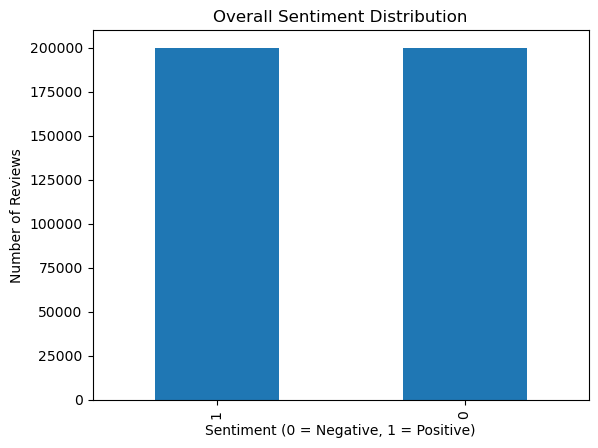

In [20]:
import matplotlib.pyplot as plt

sentiment_counts = df['label'].value_counts()
sentiment_counts.plot(kind='bar')
plt.title('Overall Sentiment Distribution')
plt.xlabel('Sentiment (0 = Negative, 1 = Positive)')
plt.ylabel('Number of Reviews')
plt.show()


#### Interpretation
From this chart, we can quickly observe whether the majority of reviews are positive or negative.  
If positive reviews dominate, it indicates general customer satisfaction; if negative ones are high, it signals dissatisfaction or product quality issues.


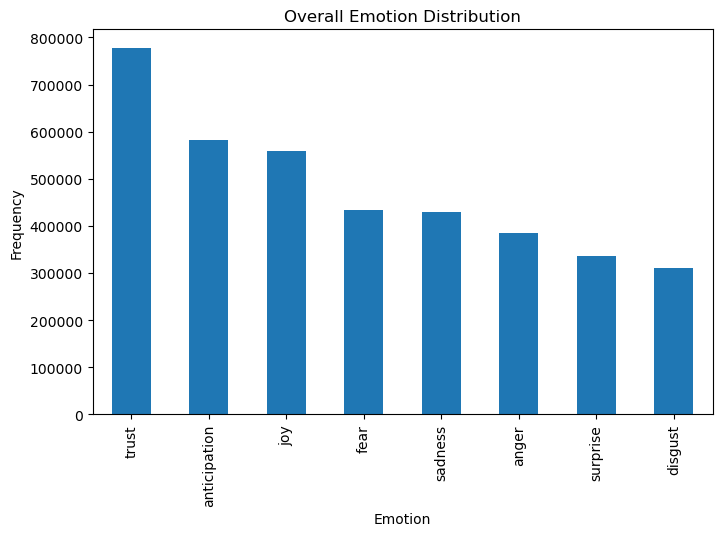

In [21]:
# Sum up detected emotions across all reviews
emotions = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']
emotion_summary = df[emotions].sum().sort_values(ascending=False)

# Plot
emotion_summary.plot(kind='bar', figsize=(8,5))
plt.title('Overall Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Frequency')
plt.show()


#### Interpretation
The bar chart highlights which emotions dominate the reviews.

For example:
- **Joy** and **Trust** appearing frequently suggest satisfaction and loyalty.  
- **Anger**, **Disgust**, or **Sadness** suggest frustration or disappointment.

Understanding these patterns helps identify emotional drivers behind sentiment — valuable for improving marketing tone or product experience.


We can combine the sentiment and emotion results to draw practical insights:

- **Positive reviews** often express emotions like *joy*, *anticipation*, and *trust* → indicating excitement and reliability.
- **Negative reviews** tend to contain *anger*, *disgust*, and *sadness* → pointing to dissatisfaction or poor performance issues.


From these results, the company or research team can:
- Identify which products or features generate negative emotions (targeted improvements).  
- Tailor marketing campaigns based on positive emotional triggers (e.g., emphasize trust and joy).  
- Monitor shifts in public sentiment over time for reputation management.  

This step connects technical sentiment analysis with **real-world decision-making**.


I successfully:
- Classified 400K+ reviews into positive and negative sentiment using Logistic Regression and VADER.
- Detected detailed emotions with the NRC Lexicon.
- Interpreted sentiment and emotion trends to reveal customer attitudes.

The combined analysis provides actionable insights for marketing, product feedback, and social sentiment tracking.
